#### Keras를 이용한 손글씨 인식 딥러닝
- Tensorflow로 작성된 프로그램은 sklearn보다 무지하게 어렵다.
- Keras는 테아노(Theano)와 TensorFlow를 Wrapping한 라이브러리

#### Data 불러오기

In [3]:
import pandas as pd
train = pd.read_csv("../Data/train_20k.csv", header=None)
train.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
test = pd.read_csv("../Data/test_1k.csv", header=None)
test.head()

,0,1,2,3,4,5,6,7,8,9,...,775,776,777,778,779,780,781,782,783,784
0,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


#### 전처리(Preprocessing)
##### 결측치 확인

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20001 entries, 0 to 20000
Columns: 785 entries, 0 to 784
dtypes: int64(785)
memory usage: 119.8 MB


In [10]:
# train 결측치
train.isnull().sum().sum()

np.int64(0)

In [11]:
# train 결측치
test.isnull().sum().sum()

np.int64(0)

##### Target Data의 비울 확인

In [13]:
import numpy as np

In [16]:
checkCount = np.unique(train[0], return_counts=True)[1]
np.min(checkCount) / np.max(checkCount)

np.float64(0.7786058746163963)

> Data의 Target 비율이 최소 77%가 넘는다

#### train과 test를 Target과 Feature로 분리하고 정규화하기

In [18]:
# Train의 Data와 Target
train_label = train.loc[:,train.columns == 0]
train_data = train.loc[:,train.columns != 0] / 255.0

In [ ]:
# Train의 Data와 Target
test_label = test.loc[:,test.columns == 0]
test_data = test.loc[:,test.columns != 0] / 255.0

----
#### Deep Learning Model 만들기

In [20]:
from tensorflow import keras
from tensorflow.keras.layers import Input

In [23]:
# 모델 생성하기
model = keras.Sequential() 
model.add(Input(shape=(784,))) # 입력층
model.add(keras.layers.Dense(100, activation='relu'))   # 은닉층은 여러개가 가능
model.add(keras.layers.Dense(10, activation='softmax')) # 출력층

# 손실함수
model.compile(
    optimizer = 'adam',
    loss='sparse_categorical_crossentropy',
    metrics = ['accuracy']
)

# 데이터 훈련하기
model.fit(
    np.array(train_data),
    np.array(train_label),
    epochs = 10
)

Epoch 1/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8820 - loss: 0.4279
Epoch 2/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9449 - loss: 0.1971
Epoch 3/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9605 - loss: 0.1394
Epoch 4/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9695 - loss: 0.1074
Epoch 5/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9745 - loss: 0.0857
Epoch 6/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9822 - loss: 0.0650
Epoch 7/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9826 - loss: 0.0590
Epoch 8/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9888 - loss: 0.0424
Epoch 9/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9909 - loss: 0.0334
Epoch 10/10
626/626 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.9935 - loss: 0.0272


#### 테스트 데이터로 평가하기


In [24]:
score = model.evaluate(test_data, test_label)
print("loss =", score[0])
print("accuracy =", score[1])

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9680 - loss: 0.0947  
loss = 0.09465280920267105
accuracy = 0.9680319428443909


----
#### test_data로 predict해보기

In [ ]:
pred = model.predict(test_data)
print("test label", test_label[:10])
print("pred", np.argmax(pred[:10])) # argmax:예측값중 최대값의 index
print("예측값:", np.argmax(pred[0:9]))

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step 
test label    0
0  7
1  2
2  1
3  0
4  4
5  1
6  4
7  9
8  5
9  9
pred 30
예측값: 30


In [33]:
# test_data의 0번값 확인
print("정답:", test_label.loc[0])
print("예측값:", np.argmax(pred[0]))

정답: 0    7
Name: 0, dtype: int64
예측값: 7


#  사용 이미지 만들기

In [47]:
from PIL import Image

In [52]:
# train_data크기
train1 = train.loc[:,train.columns != 0]
train1

,1,2,3,4,5,6,7,8,9,10,...,775,776,777,778,779,780,781,782,783,784
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19998,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
19999,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [55]:
# train1의 데이터의 50번째로 이미지 만들기
abc = np.array(train1.iloc[50]).reshape(28, 28)
abc.shape

(28, 28)

In [56]:
# Image 만들기
image = Image.fromarray((abc).astype(np.uint8))
image

In [57]:
# image 저장하기
image.save("../Data/mnist_test_3.jpg", "JPEG")

----
#### 이미지를 불러서 Predict 해보기

In [58]:
# Image 불러오기
img = Image.open("../Data/mnist_test_3.jpg")
img

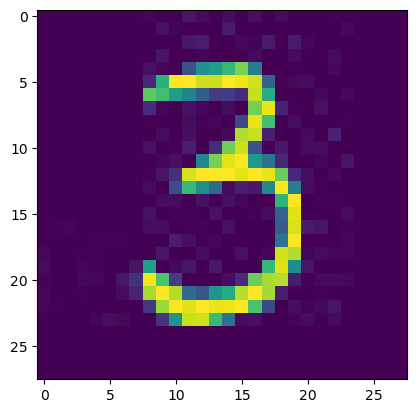

In [59]:
import matplotlib.pyplot as plt

plt.imshow(img)
plt.show()

In [61]:
# Image를 numpy배열로 변경하고 정규화 하기
imgArray = np.array(img) / 255.0
imgArray.shape

(28, 28)

In [62]:
# image를 1차원 배열로 변경
imgArray2 = imgArray.reshape(-1)
imgArray2.shape

(784,)

In [63]:
imgArray3 = imgArray2.tolist()
imgArray3

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.011764705882352941,
 0.0,
 0.0,
 0.058823529411764705,
 0.023529411764705882,
 0.0,
 0.03137254901960784,
 0.0,
 0.03529411764705882,
 0.0,
 0.027450980392156862,
 0.0,
 0.0,
 0.0,
 0.00392156862745098,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.043137254901960784,
 0.00784313725490196,
 0.0,
 0.0,
 0.0,
 0.07058823529411765,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0196078431372549,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.06274509803921569,
 0.07450980392156863,
 0.0,
 0.0,
 0.0196078431372549,
 0.00784313725490196,
 0.07058823529411765,
 0.0,
 0.07058823529411765,
 0.011764705882352941,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.050980392156862744,
 0.0,
 0.0,
 0.01568627450980392,
 0.0,
 0.0,
 0.0,
 0.023529411764705882,
 0.0,
 0.0,
 0.027450980392156862,
 0.0,
 0.0,
 0.02

In [66]:
dfArray = pd.DataFrame(imgArray3)
dfArray = dfArray.T
dfArray

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.011765,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [67]:
print("예측값 :", np.argmax(model.predict(dfArray), axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
예측값 : [3]


In [68]:
model.predict(dfArray)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step


array([[1.06612255e-07, 3.41233390e-05, 1.67045312e-06, 9.99838114e-01,
        5.40521072e-10, 9.45455613e-05, 1.57316893e-09, 3.64157593e-10,
        1.20894936e-06, 3.02562385e-05]], dtype=float32)

---
#### train1의 데이터의 150번째로 이미지 만들기

In [69]:
# train1의 데이터의 150번째로 이미지 만들기
abc150 = np.array(train1.iloc[150]).reshape(28, 28)
abc150.shape

(28, 28)

In [70]:
image = Image.fromarray((abc150).astype(np.uint8))
image

In [71]:
# image 저장하기
image.save("../Data/mnist_test_4.jpg", "JPEG")

In [72]:
# Image 불러오기
img150 = Image.open("../Data/mnist_test_4.jpg")
img150

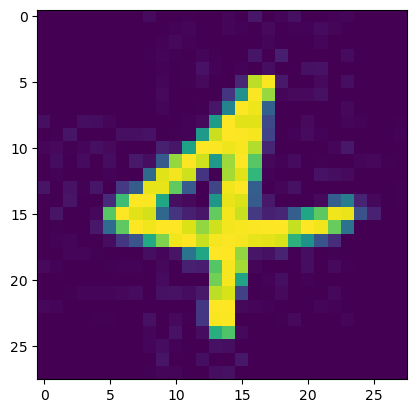

In [73]:
plt.imshow(img150)

plt.show()

In [74]:
# Image를 numpy배열로 변경하고 정규화 하기

imgArray150 = np.array(img150) / 255.0
imgArray150.shape

(28, 28)

In [75]:
# image를 1차원 배열로 변경
imgArray150_2 = imgArray150.reshape(-1)
imgArray150_2.shape

(784,)

In [76]:
imgArray150_3 = imgArray150_2.tolist()
imgArray150_3

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.027450980392156862,
 0.0,
 0.0,
 0.00392156862745098,
 0.0,
 0.0,
 0.011764705882352941,
 0.0,
 0.058823529411764705,
 0.0,
 0.01568627450980392,
 0.0392156862745098,
 0.0,
 0.0,
 0.00784313725490196,
 0.01568627450980392,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.00784313725490196,
 0.01568627450980392,
 0.0,
 0.0,
 0.01568627450980392,
 0.00784313725490196,
 0.0,
 0.023529411764705882,
 0.0,
 0.00784313725490196,
 0.00784313725490196,
 0.027450980392156862,
 0.01568627450980392,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.00784313725490196,
 0.0196078431372549,
 0.00784313725490196,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.01568627450980392,
 0.0,
 0.0,
 0.0,
 0.01568627450980392,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.00392156862745098,
 0.01568627450980392,
 0.00392156862745098,
 0.0,
 0.011764705882352941

In [77]:
dfArray150 = pd.DataFrame(imgArray150_3)
dfArray150 = dfArray150.T
dfArray150

,0,1,2,3,4,5,6,7,8,9,...,774,775,776,777,778,779,780,781,782,783
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.027451,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [78]:
print("예측값 :", np.argmax(model.predict(dfArray150), axis=1))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
예측값 : [4]


In [79]:
model.predict(dfArray150)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[7.6905462e-06, 2.1378850e-05, 2.3763954e-04, 1.3927327e-04,
        9.9496549e-01, 1.0192025e-06, 4.0761707e-03, 3.4144791e-04,
        8.7364739e-08, 2.0969495e-04]], dtype=float32)

----
#### 딥러닝 구성
##### 딥러닝 신경망의 흐름
##### 1. 입력층(Input Layer)
- 입력 데이터를 받는 층입니다. 데이터는 보통 숫자로 변환된 상태로 들어옵니다.    
- 입력층은 데이터의 특징이나 변수를 신경망에 전달 합니다.

##### 2. 은닉층(Hidden Layer)
- 입력층에서 받은 데이터를 처리하는 중간 단계 입니다. 하나 이상의 은닉층이 있을 수 있습니다.
- 각 은닉층에서는 활성화 함수(Activation Function)가 적용됩니다. 각 노드에서 계산된 값을 비선형적으로 변환하여(확률) 다음 층으로 전달 합니다.    
  대표적인 활성화 함수는 Relu, Sigmoid, Adam, Tanh

##### 3. 출력층(Output Layer)
- 은닉층에서 전달된 데이터를 최종적으로 처리하여 결과를 내는 층 입니다.
- 분류 문제라면 Softmax나 Sigmoid 같은 활성화 함수가 사용되어 예측 확률을 계산합니다.

##### 4. 손실함수(Loss Function)
- 출력층에서 나온 결과와 실제 값(정답)을 비교하여 오류를 계산합니다. 손실함수는 예측이 얼마나 잘못되었는지를 평가합니다.     
  대표적인 손실 함수로는 회귀문제에 사용되는 MAE, RMSE와 분류 문제에 사용되는 Cross Entropy가 있습니다.

##### 5. 최적화 함수(Optimization Function)
- 손실함수에서 계산된 오류를 바탕으로 네트워크의 가중치를 업데이트 합니다. 이를 통해 모델이 더 좋은 예측을 할 수 있도록 학습이 진행 됩니다.
- 대표적인 최적화 함수는 확률적 경사하강법, Adam이 있습니다.
- 최적화 함수는 역전파(BackPropagation) 과정에서 가중치와 편향을 조절하는 역할을 합니다.    
    
이 과정이 여러번 반복되면서 신경망은 학습을 통해 점점 더 좋은결과를 내놓게 됩니다.    